Network Flow Problem
-----------------------------
We will now show how to model a problem over graphs: the network flow problem as a linear program. The network flow problem involves a directed graph  𝐺
  where each edge  𝑒𝑗
  of the graph has a weight  𝐶𝑗≥0
  that denotes the "capacity" of the edge. There are two specially designated nodes in the graph: the source  𝑠
  and the sink  𝑡
 . Imagine the graph as a network of pipelines distributing water across a township, connecting the source to the sink where each edge is a pipeline with a capacity  𝐶𝑗
 . Our goal is to send as much water as possible through the pipes:

The flow in each edge must be less than its capacity.
The flow in each edge must be along the direction of the edge.
For each node that is not the source or sink, the sum of flows along edges that are incoming to the node must equal the sum of all flows along outgoing edges.
Note that this constraint does not apply to the source or sink nodes.
The total flow through the network is therefore the total flow leaving the source  𝑠
  or equivalently the total flow entering the sink.

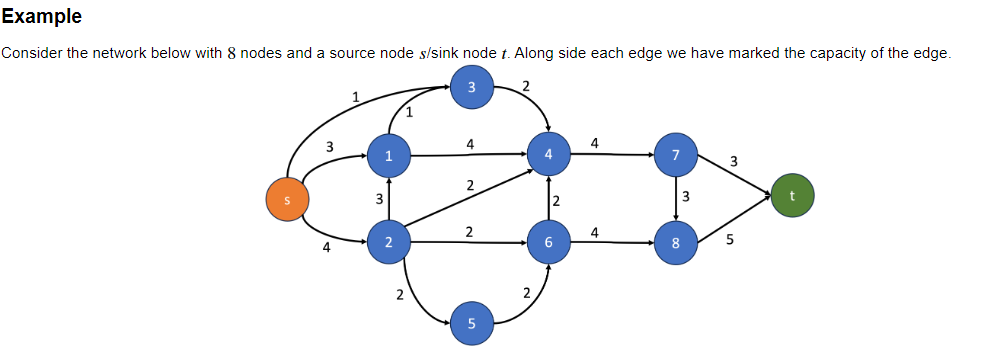
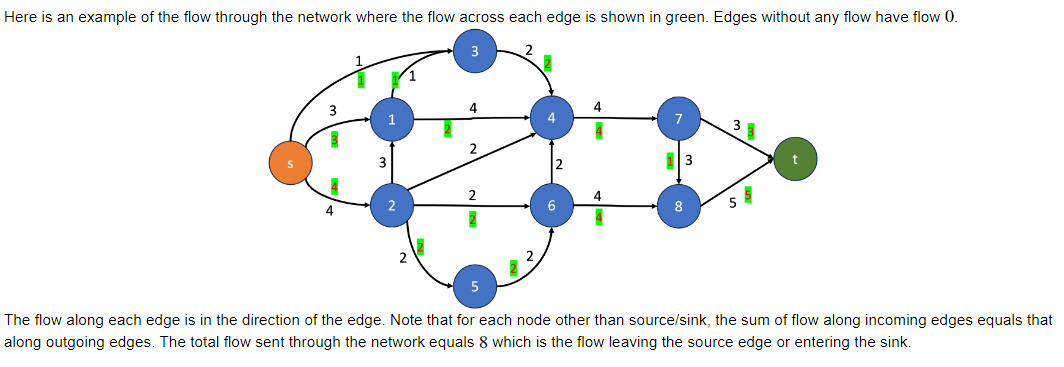

Network flow as an LP
-----------------------------
We can use linear programming solvers to solve network flow problems over graphs. LPs can solve network flows efficiently although there are dedicated algorithms that are faster for solving network flow problems (eg., see Edmonds-Karp algorithm or Ford-Fulkerson algorithm).

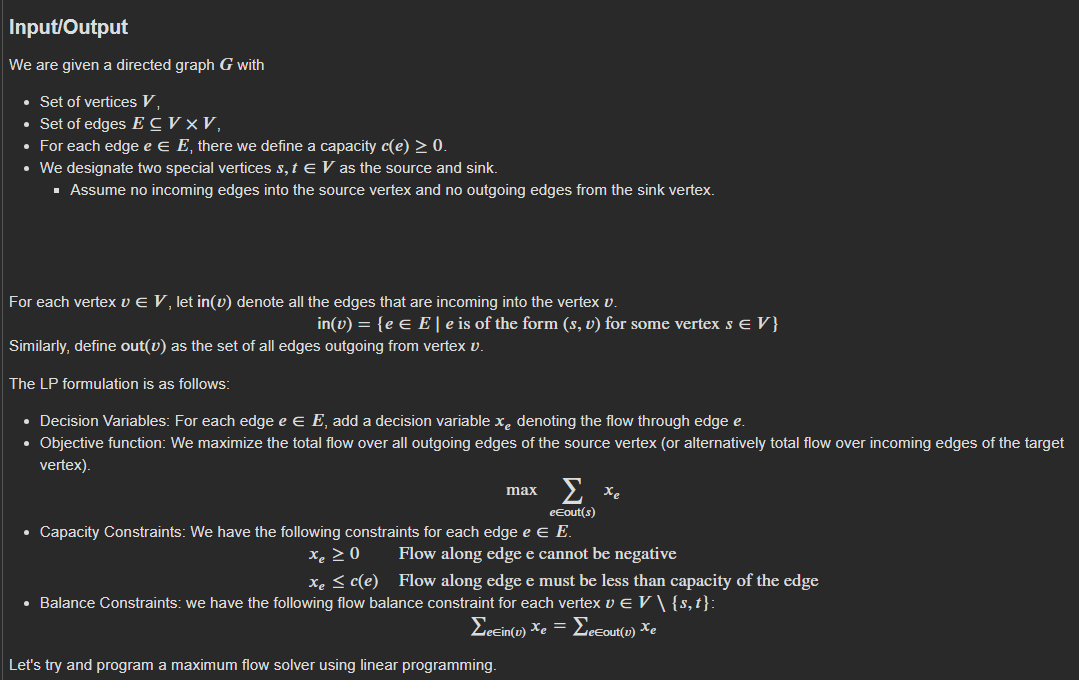

In [1]:

try:
    %load_ext autotime
except:
    !pip install ipython-autotime
    %load_ext autotime

try:
    %load_ext networkx
except:
    !pip install networkx

    
try:
    %load_ext matplotlib
except:
    !pip install matplotlib
    

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.2 MB/s eta 0:00:00
The matplotlib module is not an IPython extension.
time: 17.2 s (started: 2024-10-19 20:24:44 -07:00)


In [3]:
from pulp import *
import networkx as nx
from matplotlib import pyplot as plt 

class WeightedDirectedGraph:
    def __init__(self, num_vertices, source_vertex_id, sink_vertex_id):
        self.__n = num_vertices
        self.__src = source_vertex_id
        self.__sink = sink_vertex_id
        self.__incoming = {}
        self.__outgoing = {}
        self.__edges = [] 
        self.__flow_lp_vars = []
        self.__lp_model = LpProblem('Flow Problem', LpMaximize)
        
    
    def add_edge(self, u, v, cap):
        assert cap > 0.0, 'capacity must be positive'
        assert u != self.__sink, 'Adding an edge leaving sink - not allowed'
        assert v != self.__src, 'Adding an edge entering source - not allowed'
        # Assign a edge id to the edge we are going to add
        edge_id = len(self.__edges)
        # Append the source/dest/capacity
        self.__edges.append( (u,v,cap))
        # Create a new LP variable
        lp_var = LpVariable(f'x_{edge_id}', 0.0, cap) # Create a decision variable with bounds between 0.0 and capacity of edge.
        # Append it to the list of decision variables
        self.__flow_lp_vars.append(lp_var)
        # Add the edge as incoming to vertex v
        if v in self.__incoming:
            self.__incoming[v].append(edge_id)
        else:
            lst = [edge_id]
            self.__incoming[v] = lst
        # add the edge as outgoing to vertex u
        if u in self.__outgoing:
            self.__outgoing[u].append(edge_id)
        else:
            lst=[edge_id]
            self.__outgoing[u] = lst 
        
    # This is a useful routine that uses the networkx library to 
    # draw the graph. We provide the option to draw the graph with just edge capacities
    # or to draw the graph showing the flow through each edge.
    def visualize_graph(self, viz_flow = False): # set viz_flow to True only if you calculated the flow.
        G = nx.DiGraph()
        G.add_nodes_from(range(self.__n))
        color_map = ['red' if j == self.__src else ('green' if j == self.__sink else 'blue') for j in range(self.__n)]
        G.add_weighted_edges_from(self.__edges)
        pos=nx.circular_layout(G)
        plt.figure(figsize=(10,5))
        ax = plt.gca()
        title = 'Graph with Edge Capacities' if not viz_flow else 'Graph with Network Flow Solution'
        ax.set_title(f'Graph with {title}')
        nx.draw(G, pos=pos, node_color=color_map, with_labels=True)
        if viz_flow:
            for edge_id in range(len(self.__edges)):
                (u,v,_) = self.__edges[edge_id]
                flow = self.__flow_lp_vars[edge_id].varValue 
                G.edges[u,v]['flow'] = flow
            labels = nx.get_edge_attributes(G,'flow')
            nx.draw_networkx_edge_labels(G,pos, edge_labels=labels)
        
        else:
            labels = nx.get_edge_attributes(G,'weight')
            nx.draw_networkx_edge_labels(G,pos, edge_labels=labels)
        
        
    def solve_flow_problem(self):
        # Objective is simply sum of all outgoing variables at source
        # Add the objective to the problem
        s = self.__src
        if s not in self.__outgoing:
            print('Warning: no outgoing edges at source. Max flow is trivially 0 -- bailing out.')
        else:
            lst_of_edge_ids = self.__outgoing[s]
            ob_expr = sum([self.__flow_lp_vars[edge] for edge in lst_of_edge_ids])
            self.__lp_model += ob_expr 
        # Add flow balance constraints
        for i in range(self.__n):
            if i != self.__src and i!= self.__sink: 
                incoming_lst = self.__incoming[i] if i in self.__incoming else []
                outgoing_lst = self.__outgoing[i] if i in self.__outgoing else [] 
                total_incoming_flow = sum([self.__flow_lp_vars[edge] for edge in incoming_lst])
                total_outgoing_flow = sum([self.__flow_lp_vars[edge] for edge in outgoing_lst])
                self.__lp_model += total_incoming_flow == total_outgoing_flow
        # Solve the LP
        self.__lp_model.solve()
        # Print the solution
        m = len(self.__edges)
        for i in range(m):
            v = self.__flow_lp_vars[i]
            (x, y, _) = self.__edges[i]
            print(f'Edge: {x} -> {y} : flow is {v.varValue}')
        print(f'Total flow is {value(self.__lp_model.objective)}')

time: 15 ms (started: 2024-10-19 20:26:37 -07:00)


C:\Users\hramm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pulp\pulp.py:1298: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


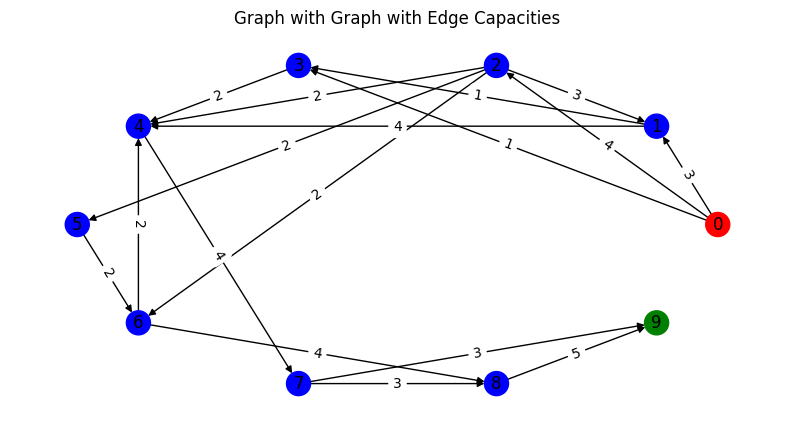

time: 578 ms (started: 2024-10-19 20:28:23 -07:00)


In [4]:
G = WeightedDirectedGraph(10, 0, 9)
G.add_edge(0, 1, 3)
G.add_edge(0, 2, 4)
G.add_edge(0, 3, 1)
G.add_edge(1, 3, 1)
G.add_edge(1, 4, 4)
G.add_edge(2, 1, 3)
G.add_edge(2, 4, 2)
G.add_edge(2, 5, 2)
G.add_edge(2, 6, 2)
G.add_edge(3, 4, 2)
G.add_edge(4, 7, 4)
G.add_edge(5, 6, 2)
G.add_edge(6, 4, 2)
G.add_edge(6, 8, 4)
G.add_edge(7, 8, 3)
G.add_edge(7, 9, 3)
G.add_edge(8, 9, 5)
G.visualize_graph()

Edge: 0 -> 1 : flow is 3.0
Edge: 0 -> 2 : flow is 4.0
Edge: 0 -> 3 : flow is 1.0
Edge: 1 -> 3 : flow is 0.0
Edge: 1 -> 4 : flow is 3.0
Edge: 2 -> 1 : flow is 0.0
Edge: 2 -> 4 : flow is 0.0
Edge: 2 -> 5 : flow is 2.0
Edge: 2 -> 6 : flow is 2.0
Edge: 3 -> 4 : flow is 1.0
Edge: 4 -> 7 : flow is 4.0
Edge: 5 -> 6 : flow is 2.0
Edge: 6 -> 4 : flow is 0.0
Edge: 6 -> 8 : flow is 4.0
Edge: 7 -> 8 : flow is 1.0
Edge: 7 -> 9 : flow is 3.0
Edge: 8 -> 9 : flow is 5.0
Total flow is 8.0


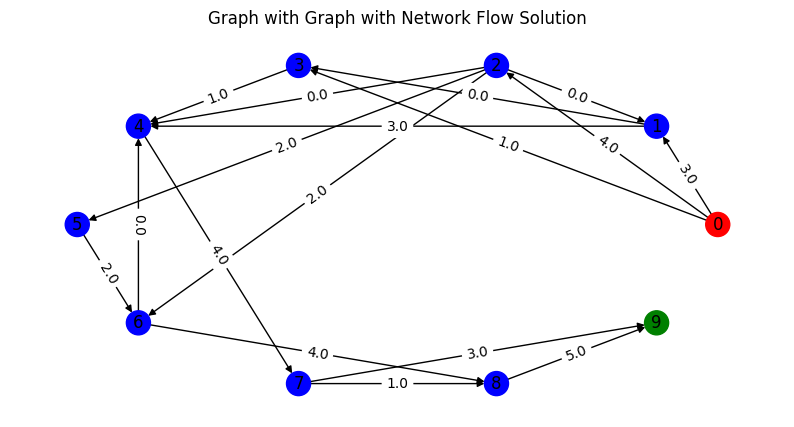

time: 328 ms (started: 2024-10-19 20:30:14 -07:00)


In [5]:
G.solve_flow_problem()
G.visualize_graph(True)